In [53]:
# Install needed libraries
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
import lightgbm as lgb
import xgboost as xgb
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import seaborn as sns

In [ ]:
# Compile transcriptome tsvs into one pandas dataframe

# Read the files
df1 = pd.read_csv('Data/TCGA_Transcriptome/TCGA-KICH.transcriptome.tsv', sep='\t')
df2 = pd.read_csv('Data/TCGA_Transcriptome/TCGA-KIRC.transcriptome.tsv', sep='\t')
df3 = pd.read_csv('Data/TCGA_Transcriptome/TCGA-KIRP.transcriptome.tsv', sep='\t')

# Get the name of the first (gene name) column
gene_col = df1.columns[0]

# Set gene name as index for all three
df1 = df1.set_index(gene_col)
df2 = df2.set_index(gene_col)
df3 = df3.set_index(gene_col)

# Concatenate along columns (axis=1)
combined_df = pd.concat([df1, df2, df3], axis=1)

# Reset index to make gene names a column again
combined_df1 = combined_df.reset_index().copy()

print(f"\nTranscriptome combined dataframe shape: {combined_df1.shape}")


Transcriptome combined dataframe shape: (60660, 1025)


/tmp/ipykernel_3408822/2937472606.py:20: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  combined_df1 = combined_df.reset_index()


In [15]:
# Combine clinical data tsvs into one pandas dataframe and drop all unneeded columns

# Read the files
df1 = pd.read_csv('Data/TCGA_Clinical/TCGA-KICH.clinical.tsv', sep='\t')
df2 = pd.read_csv('Data/TCGA_Clinical/TCGA-KIRC.clinical.tsv', sep='\t')
df3 = pd.read_csv('Data/TCGA_Clinical/TCGA-KIRP.clinical.tsv', sep='\t')

# Assign a list of columns we will keep
columns_to_keep = ['sample', 'primary_diagnosis.diagnoses']

# Create new dataframes that ONLY have the columns we want
df1a = df1[columns_to_keep]
df2a = df2[columns_to_keep]
df3a = df3[columns_to_keep]

# Concatenate along rows (axis=0)
combined_df2 = pd.concat([df1a, df2a, df3a], axis=0)

print(f"\nClinical combined dataframe shape: {combined_df2.shape}")


Clinical combined dataframe shape: (1407, 2)


In [16]:
# Make sure only samples present in BOTH dataframes are included
# Extract names from each dataframe
names_in_columns = set(combined_df1.columns)  # names from df1's column headers
first_col = combined_df2.columns[0]           # get the name of df2's first column
names_in_rows = set(combined_df2[first_col])  # names from df2's first column

# Find names present in BOTH
common_names = names_in_columns & names_in_rows

print(f"Names in df1 (columns): {len(names_in_columns)}")
print(f"Names in df2 (rows):    {len(names_in_rows)}")
print(f"Names in common:        {len(common_names)}")

# Filter df1: keep only columns whose header is a common name
# (preserve any non-name columns like a gene/ID column if needed)
non_name_cols = [combined_df1.columns[0]]  # e.g., keep the first column (gene names, etc.)
name_cols_to_keep = [c for c in combined_df1.columns if c in common_names]
transcriptome = combined_df1[non_name_cols + name_cols_to_keep]
# Transpose df1: make the Subject ID the row names instead, to match df2
transcriptome = transcriptome.set_index(transcriptome.columns[0]) # set Ensembl_ID as index
transcriptome = transcriptome.T # samples as rows, genes as columns
transcriptome.index.name = 'sample' # name the index

# Filter df2: keep only rows where the first column value is a common name
clinical = combined_df2[combined_df2[first_col].isin(common_names)]
clinical.columns = ['sample', 'primary_diagnosis']
clinical = clinical.set_index('sample')

print(f"\nTranscriptome dataframe filtered shape: {transcriptome.shape}")
print(f"Clinical dataframe filtered shape: {clinical.shape}")

#transcriptome.to_csv(r'Data/TCGA_Transcriptome/filtered_transcriptome.tsv', sep='\t', index=False)
#clinical.to_csv(r'Data/TCGA_Clinical/filtered_clinical.tsv', sep='\t', index=False)

Names in df1 (columns): 1025
Names in df2 (rows):    1407
Names in common:        1024

Transcriptome dataframe filtered shape: (1024, 60660)
Clinical dataframe filtered shape: (1024, 1)


In [17]:
# Variance filtering: only include the genes with the top 5000 variances.
gene_variances = transcriptome.var(axis=0) # variance per gene
top_genes = gene_variances.nlargest(5000).index # top 5000 gene IDs
transcriptome = transcriptome[top_genes] # shape: (1025, 5000)

print(f"X shape after variance filtering: {transcriptome.shape}")
#transcriptome.to_csv(r'Data/TCGA_Transcriptome/varianced_transcriptome.tsv', sep='\t', index=False)

X shape after variance filtering: (1024, 5000)


In [18]:
# Convert target labels to numbers
# Combine labels for all Renal Cell Carcinoma types
clinical['primary_diagnosis'] = clinical['primary_diagnosis'].replace({
    'Renal cell carcinoma, NOS': 'Renal cell carcinoma, NOS or chromophobe type',
    'Renal cell carcinoma, chromophobe type': 'Renal cell carcinoma, NOS or chromophobe type'})

le = LabelEncoder()
clinical['label'] = le.fit_transform(clinical['primary_diagnosis'])

print(f"\nClass mapping:")
for i, cls in enumerate(le.classes_):
    print(f"  {i}: {cls}")

#clinical.to_csv(r'Data/TCGA_Clinical/labeled_clinical.tsv', sep='\t', index=False)


Class mapping:
  0: Clear cell adenocarcinoma, NOS
  1: Papillary adenocarcinoma, NOS
  2: Renal cell carcinoma, NOS or chromophobe type


In [56]:
# Align x and y, then split
# Align on shared samples (same order)
common_samples = transcriptome.index.intersection(clinical.index)
X = transcriptome.loc[common_samples]
y = clinical.loc[common_samples, 'label']

print(f"\nFinal X shape: {X.shape}")
print(f"Final y shape: {y.shape}")
print(f"\nClass distribution:\n{y.value_counts().sort_index()}")

# Stratified 80/20 split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y          # preserves subtype proportions in both splits
)

# Linearly scales the data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)  # fit ONLY on train
X_test_scaled = scaler.transform(X_test)         # transform test using train's parameters

# PCA scales the data
pca = PCA(random_state=42)
pca.fit(X_train_scaled)
cumulative_variance = pca.explained_variance_ratio_.cumsum()
n_components_90 = (cumulative_variance < 0.90).sum() + 1
print(f"\nComponents needed for 90% variance: {n_components_90}")

pca = PCA(n_components=n_components_90, random_state=42)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca  = pca.transform(X_test_scaled)


# combine linearly scaled train and test sets to store
X_all = np.vstack([X_train_scaled, X_test_scaled])      # Combines train and test for features
y_all = np.concatenate([y_train, y_test])   # Combines train and test labels
df = pd.DataFrame(X_all)    # Creates dataframe of features
df["label"] = y_all         # Adds label to dataframe
#df.to_csv("Data/Linear_Scaled.tsv", sep="\t", index=False)

# combine PCA scaled train and test sets to store
X_all_pca = np.vstack([X_train_pca, X_test_pca])      # Combines train and test for features
df = pd.DataFrame(X_all_pca)        # Creates dataframe for features
df["label"] = y_all             # Add label to dataframe
#df.to_csv("Data/PCA_Scaled.tsv", sep="\t", index=False)

print(f"\nX_train: {X_train.shape}, X_test: {X_test.shape}")
print(f"y_train: {y_train.shape}, y_test: {y_test.shape}")
print(f"X_train_pca: {X_train_pca.shape}, X_test_pca: {X_train_pca.shape}")



Final X shape: (1024, 5000)
Final y shape: (1024,)

Class distribution:
label
0    596
1    323
2    105
Name: count, dtype: int64

Components needed for 90% variance: 183

X_train: (819, 5000), X_test: (205, 5000)
y_train: (819,), y_test: (205,)
X_train_pca: (819, 183), X_test_pca: (819, 183)


In [20]:
# Model 1: Logistic Regression with L1 regularization
lr_l1 = LogisticRegression(
    solver='saga',
    l1_ratio=1.0,             # 1.0 = pure L1
    C=1.0,
    class_weight='balanced',
    max_iter=10000,
    tol=0.01,
    random_state=42)

lr_l1.fit(X_train_scaled, y_train)
y_pred_lr_l1 = lr_l1.predict(X_test_scaled)
cm1 = confusion_matrix(y_test, y_pred_lr_l1)

# ── METRICS ──────────────────────────────────────────────────────────────────
print("=== Logistic Regression (L1 Regularization) ===")
print(f"Accuracy: {accuracy_score(y_test, y_pred_lr_l1):.4f}")
print("Classification Report:")
print(classification_report(y_test, y_pred_lr_l1, target_names=le.classes_))

=== Logistic Regression (L1 Regularization) ===
Accuracy: 0.9317
Classification Report:
                                               precision    recall  f1-score   support

               Clear cell adenocarcinoma, NOS       0.99      0.93      0.96       119
                Papillary adenocarcinoma, NOS       0.94      0.92      0.93        65
Renal cell carcinoma, NOS or chromophobe type       0.69      0.95      0.80        21

                                     accuracy                           0.93       205
                                    macro avg       0.87      0.94      0.90       205
                                 weighted avg       0.94      0.93      0.93       205



In [21]:
# Model 2: SVM with linear kernel
# ── SVM: LINEAR KERNEL ───────────────────────────────────────────────────────
svm_linear = SVC(
    kernel='linear',
    C=1.0,
    class_weight='balanced',
    random_state=42)

svm_linear.fit(X_train_scaled, y_train)
y_pred_svm_linear = svm_linear.predict(X_test_scaled)
cm2 = confusion_matrix(y_test, y_pred_svm_linear)

# ── METRICS ──────────────────────────────────────────────────────────────────
print("=== SVM (Linear Kernel) ===")
print(f"Accuracy: {accuracy_score(y_test, y_pred_svm_linear):.4f}")
print("Classification Report:")
print(classification_report(y_test, y_pred_svm_linear, target_names=le.classes_))

=== SVM (Linear Kernel) ===
Accuracy: 0.9220
Classification Report:
                                               precision    recall  f1-score   support

               Clear cell adenocarcinoma, NOS       0.97      0.95      0.96       119
                Papillary adenocarcinoma, NOS       0.91      0.91      0.91        65
Renal cell carcinoma, NOS or chromophobe type       0.71      0.81      0.76        21

                                     accuracy                           0.92       205
                                    macro avg       0.86      0.89      0.87       205
                                 weighted avg       0.93      0.92      0.92       205



In [22]:
# Model 3: Random Forest
# ── Random Forest ──────────────────────────────────────────
clf = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    class_weight="balanced")

clf.fit(X_train, y_train)
y_pred_clf = clf.predict(X_test)
cm3 = confusion_matrix(y_test, y_pred_clf)

# ── METRICS ──────────────────────────────────────────────────────────────────
print("=== Random Forest ===")
print(f"Accuracy: {accuracy_score(y_test, y_pred_clf):.4f}")
print("Classification Report:")
print(classification_report(y_test, y_pred_clf, target_names=le.classes_))

=== Random Forest ===
Accuracy: 0.9171
Classification Report:
                                               precision    recall  f1-score   support

               Clear cell adenocarcinoma, NOS       0.93      0.96      0.94       119
                Papillary adenocarcinoma, NOS       0.92      0.89      0.91        65
Renal cell carcinoma, NOS or chromophobe type       0.84      0.76      0.80        21

                                     accuracy                           0.92       205
                                    macro avg       0.90      0.87      0.88       205
                                 weighted avg       0.92      0.92      0.92       205



In [23]:
# Model 4: XG Boost
# ── XG Boost ──────────────────────────────────────────
xgboost = xgb.XGBClassifier(
    objective="multi:softprob",   # multiclass classification, outputs class probabilities
    num_class=len(le.classes_),   # number of classes (3)
    n_estimators=500,             # max number of trees 
    max_depth=6,                  # tree depth 
    learning_rate=0.05,           # step size per tree 
    subsample=0.8,                # use 80% of samples per tree 
    colsample_bytree=0.3,         # use 30% of features per tree 
    reg_alpha=1.0,                # L1 regularization 
    reg_lambda=1.0,               # L2 regularization 
    tree_method="hist",           # fast, memory-efficient tree building
    random_state=42,              # ensures reproducibility
    n_jobs=-1,                    # use all CPU cores
    eval_metric="mlogloss",       # multiclass log loss for validation monitoring
    verbosity=0)

xgboost.fit(X_train, y_train, verbose=False) # Turns off output)
y_pred_xg = xgboost.predict(X_test)
cm4 = confusion_matrix(y_test, y_pred_xg)

# ── METRICS ──────────────────────────────────────────────────────────────────
print("=== XG Boost ===")
print(f"Accuracy: {accuracy_score(y_test, y_pred_xg):.4f}")
print("Classification Report:")
print(classification_report(y_test, y_pred_xg, target_names=le.classes_))

=== XG Boost ===
Accuracy: 0.9317
Classification Report:
                                               precision    recall  f1-score   support

               Clear cell adenocarcinoma, NOS       0.94      0.98      0.96       119
                Papillary adenocarcinoma, NOS       0.92      0.89      0.91        65
Renal cell carcinoma, NOS or chromophobe type       0.94      0.76      0.84        21

                                     accuracy                           0.93       205
                                    macro avg       0.93      0.88      0.90       205
                                 weighted avg       0.93      0.93      0.93       205



In [24]:
# Model 5: Logistic Regression with Elastic Net Regularization
# ── LOGISTIC REGRESSION: ELASTICNET ──────────────────────────────────────────
lr_en = LogisticRegression(
    solver='saga',
    max_iter=5000,
    tol=0.01,
    l1_ratio=0.5,
    C=1.0,
    class_weight='balanced',
    random_state=42)

lr_en.fit(X_train_scaled, y_train)
y_pred_lr_en = lr_en.predict(X_test_scaled)
cm5 = confusion_matrix(y_test, y_pred_lr_en)

# ── METRICS ──────────────────────────────────────────────────────────────────
print("=== Logistic Regression (Elastic Net) ===")
print(f"Accuracy: {accuracy_score(y_test, y_pred_lr_en):.4f}")
print("Classification Report:")
print(classification_report(y_test, y_pred_lr_en, target_names=le.classes_))

=== Logistic Regression (Elastic Net) ===
Accuracy: 0.9268
Classification Report:
                                               precision    recall  f1-score   support

               Clear cell adenocarcinoma, NOS       0.99      0.92      0.96       119
                Papillary adenocarcinoma, NOS       0.92      0.92      0.92        65
Renal cell carcinoma, NOS or chromophobe type       0.69      0.95      0.80        21

                                     accuracy                           0.93       205
                                    macro avg       0.87      0.93      0.89       205
                                 weighted avg       0.94      0.93      0.93       205



In [25]:
# Model 6: Light GBM
# ── LIGHTGBM ────────────────────────────────────────────────────────
lgbm = lgb.LGBMClassifier(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    class_weight='balanced',
    random_state=42,
    verbosity=-1)

lgbm.fit(X_train, y_train)
y_pred_lgbm = lgbm.predict(X_test)
cm6 = confusion_matrix(y_test, y_pred_lgbm)

# ── METRICS ──────────────────────────────────────────────────────────────────
print("=== LightGBM ===")
print(f"Accuracy:  {accuracy_score(y_test, y_pred_lgbm):.4f}")
print("Classification Report:")
print(classification_report(y_test, y_pred_lgbm, target_names=le.classes_))

=== LightGBM ===
Accuracy:  0.9366
Classification Report:
                                               precision    recall  f1-score   support

               Clear cell adenocarcinoma, NOS       0.96      0.97      0.97       119
                Papillary adenocarcinoma, NOS       0.92      0.92      0.92        65
Renal cell carcinoma, NOS or chromophobe type       0.84      0.76      0.80        21

                                     accuracy                           0.94       205
                                    macro avg       0.91      0.89      0.90       205
                                 weighted avg       0.94      0.94      0.94       205



In [26]:
# Model 7: SVM with RBM kernel
# ── SVM (RBF KERNEL) ────────────────────────────────────────────────
svm_rbf = SVC(
    kernel='rbf',
    C=1.0,
    gamma='scale',
    class_weight='balanced',
    random_state=42)

svm_rbf.fit(X_train_scaled, y_train)
y_pred_rbf = svm_rbf.predict(X_test_scaled)
cm7 = confusion_matrix(y_test, y_pred_rbf)

# ── METRICS ──────────────────────────────────────────────────────────────────
print("=== SVM (RBF Kernel) ===")
print(f"Accuracy: {accuracy_score(y_test, y_pred_rbf):.4f}")
print("Classification Report:")
print(classification_report(y_test, y_pred_rbf, target_names=le.classes_))

=== SVM (RBF Kernel) ===
Accuracy: 0.8927
Classification Report:
                                               precision    recall  f1-score   support

               Clear cell adenocarcinoma, NOS       0.96      0.92      0.94       119
                Papillary adenocarcinoma, NOS       0.92      0.86      0.89        65
Renal cell carcinoma, NOS or chromophobe type       0.60      0.86      0.71        21

                                     accuracy                           0.89       205
                                    macro avg       0.82      0.88      0.84       205
                                 weighted avg       0.91      0.89      0.90       205



In [27]:
# Model 8: MLP after PCA dimensionality reduction
# ── Multi-Level Perceptron ─────────────────────────────────────────────────────────────
mlp = MLPClassifier(
    hidden_layer_sizes=(128, 64),   # two hidden layers
    activation='relu',
    solver='adam',
    alpha=0.001,                    # L2 regularization
    max_iter=1000,
    random_state=42)

mlp.fit(X_train_pca, y_train)
y_pred_mlp = mlp.predict(X_test_pca)
cm8 = confusion_matrix(y_test, y_pred_mlp)

# ── METRICS ──────────────────────────────────────────────────────────────────
print("=== MLP Neural Network (after PCA) ===")
print(f"Accuracy: {accuracy_score(y_test, y_pred_mlp):.4f}")
print("Classification Report:")
print(classification_report(y_test, y_pred_mlp, target_names=le.classes_))

=== MLP Neural Network (after PCA) ===
Accuracy: 0.9268
Classification Report:
                                               precision    recall  f1-score   support

               Clear cell adenocarcinoma, NOS       0.94      0.97      0.95       119
                Papillary adenocarcinoma, NOS       0.91      0.91      0.91        65
Renal cell carcinoma, NOS or chromophobe type       0.89      0.76      0.82        21

                                     accuracy                           0.93       205
                                    macro avg       0.91      0.88      0.89       205
                                 weighted avg       0.93      0.93      0.93       205



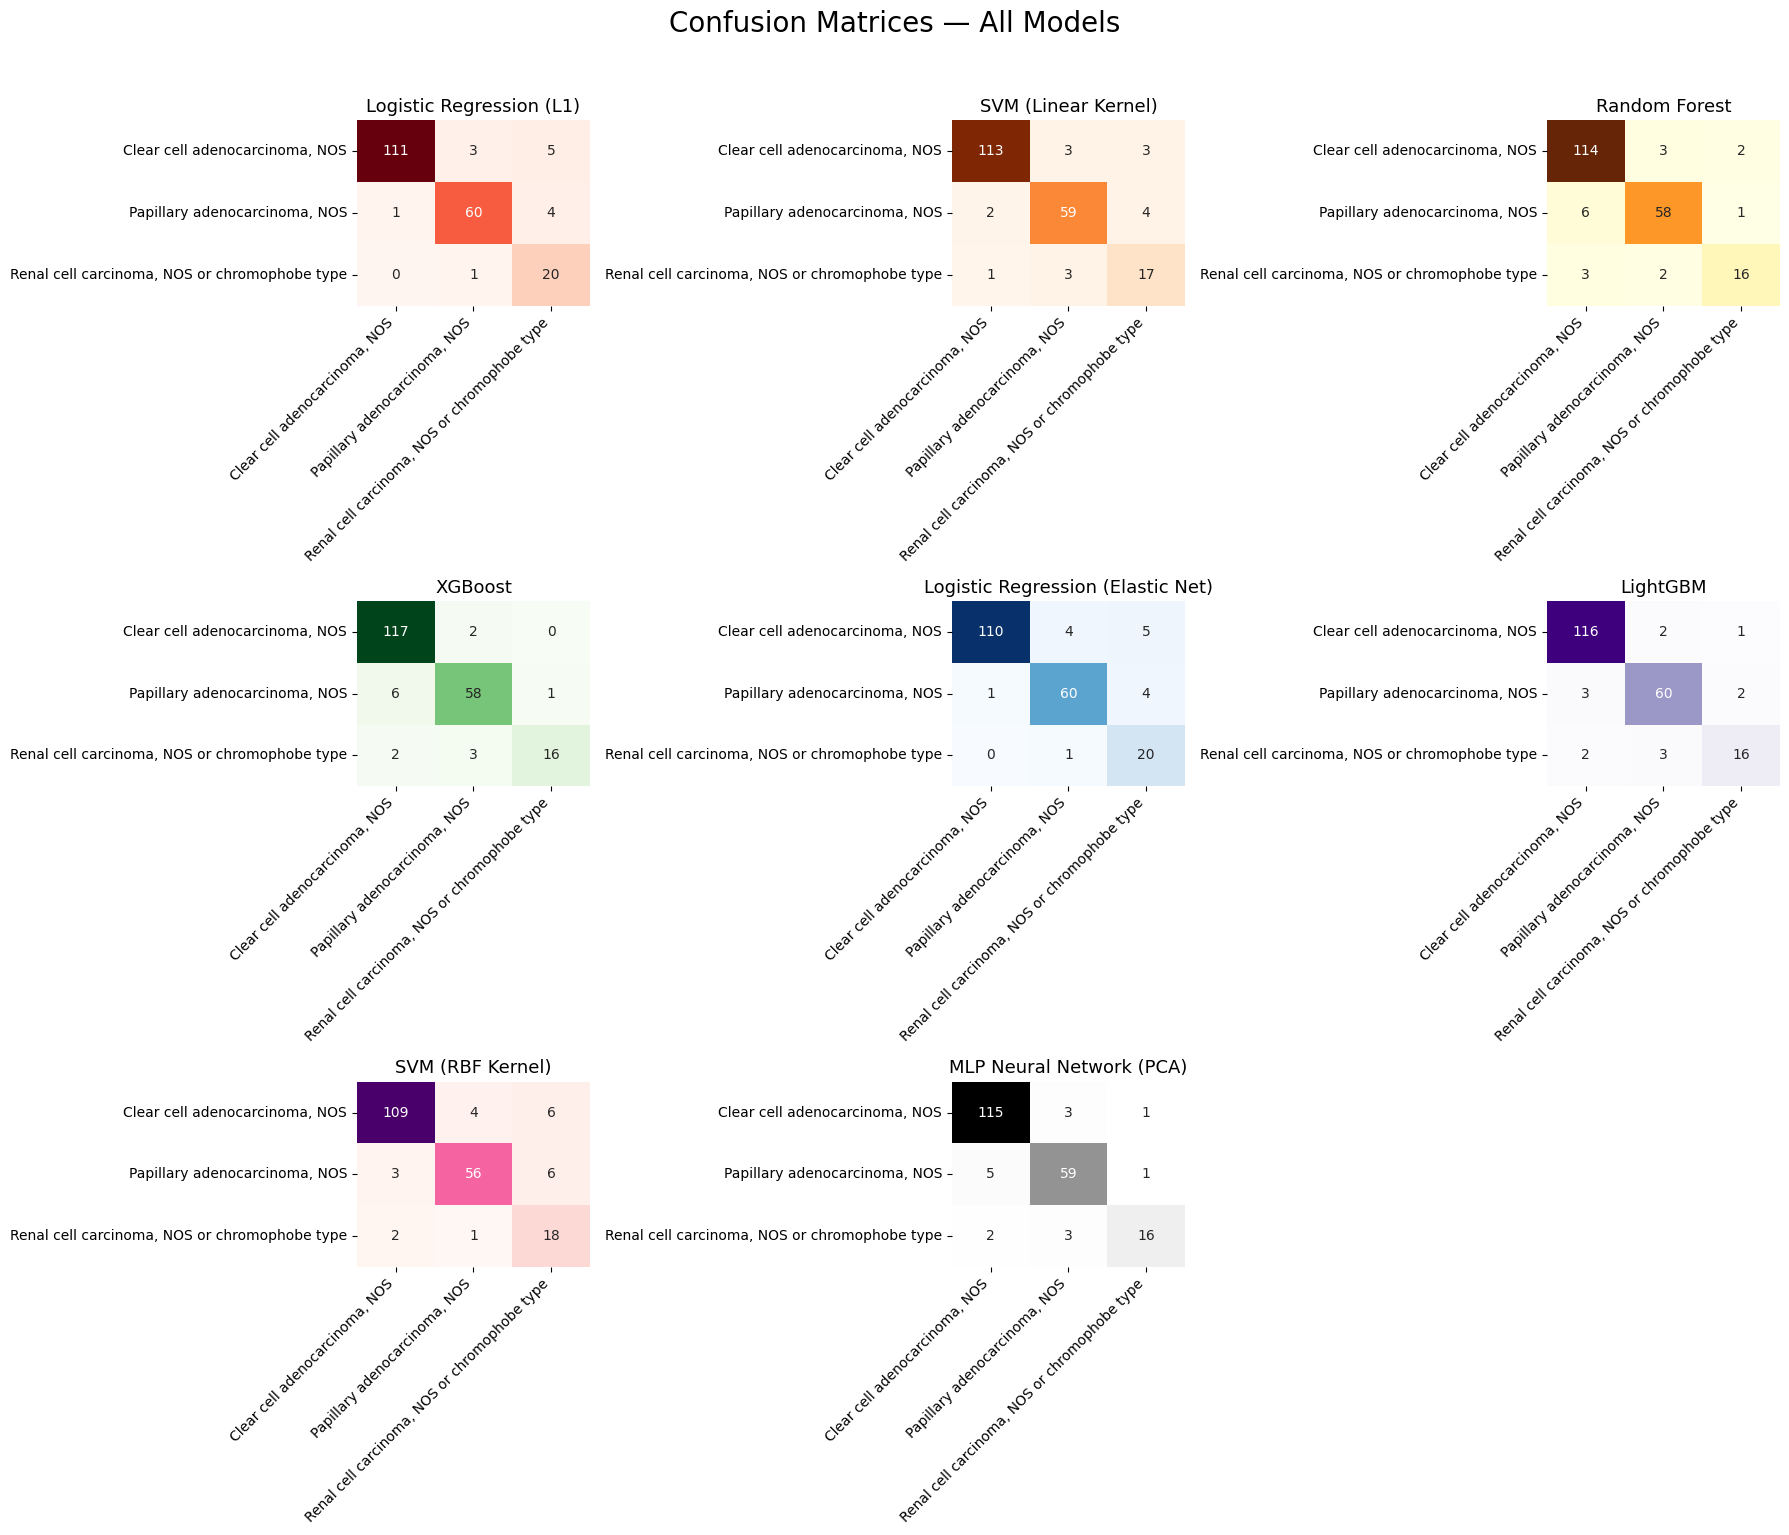

In [28]:
fig, axes = plt.subplots(3, 3, figsize=(18,15))

cms = [cm1, cm2, cm3, cm4, cm5, cm6, cm7, cm8]
titles = [
    'Logistic Regression (L1)',
    'SVM (Linear Kernel)',
    'Random Forest',
    'XGBoost',
    'Logistic Regression (Elastic Net)',
    'LightGBM',
    'SVM (RBF Kernel)',
    'MLP Neural Network (PCA)']

cmaps = ['Reds', 'Oranges', 'YlOrBr', 'Greens', 'Blues', 'Purples', 'RdPu', 'Greys']

for ax, cm, title, cmap in zip(axes.flatten(), cms, titles, cmaps):
    sns.heatmap(cm, annot=True, fmt='d', cmap=cmap,
                xticklabels=le.classes_, yticklabels=le.classes_,
                ax=ax, cbar=False)
    ax.set_title(title, fontsize=13)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=10)
    ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=10)

# Hide the last empty subplot if odd number of models
for ax in axes.flatten()[len(cms):]:
    ax.set_visible(False)

plt.suptitle('Confusion Matrices — All Models', fontsize=20, y=1.02)
plt.tight_layout()
plt.show()

In [29]:
results = {
    'Model': ['LR (L1)', 'SVM Linear', 'Random Forest', 'XGBoost', 
              'LR (ElasticNet)', 'LightGBM', 'SVM RBF', 'MLP (PCA)'],
    'Accuracy': [
        accuracy_score(y_test, y_pred_lr_l1),
        accuracy_score(y_test, y_pred_svm_linear),
        accuracy_score(y_test, y_pred_clf),
        accuracy_score(y_test, y_pred_xg),
        accuracy_score(y_test, y_pred_lr_en),
        accuracy_score(y_test, y_pred_lgbm),
        accuracy_score(y_test, y_pred_rbf),
        accuracy_score(y_test, y_pred_mlp)
    ],
    'Macro F1': [
        f1_score(y_test, y_pred_lr_l1, average='macro'),
        f1_score(y_test, y_pred_svm_linear, average='macro'),
        f1_score(y_test, y_pred_clf, average='macro'),
        f1_score(y_test, y_pred_xg, average='macro'),
        f1_score(y_test, y_pred_lr_en, average='macro'),
        f1_score(y_test, y_pred_lgbm, average='macro'),
        f1_score(y_test, y_pred_rbf, average='macro'),
        f1_score(y_test, y_pred_mlp, average='macro')
    ]
}

results_df = pd.DataFrame(results).sort_values('Macro F1', ascending=False)
print(results_df.to_string(index=False))

          Model  Accuracy  Macro F1
        XGBoost  0.931707  0.902457
        LR (L1)  0.931707  0.897091
       LightGBM  0.936585  0.896581
      MLP (PCA)  0.926829  0.894187
LR (ElasticNet)  0.926829  0.893200
  Random Forest  0.917073  0.882800
     SVM Linear  0.921951  0.874983
        SVM RBF  0.892683  0.843465


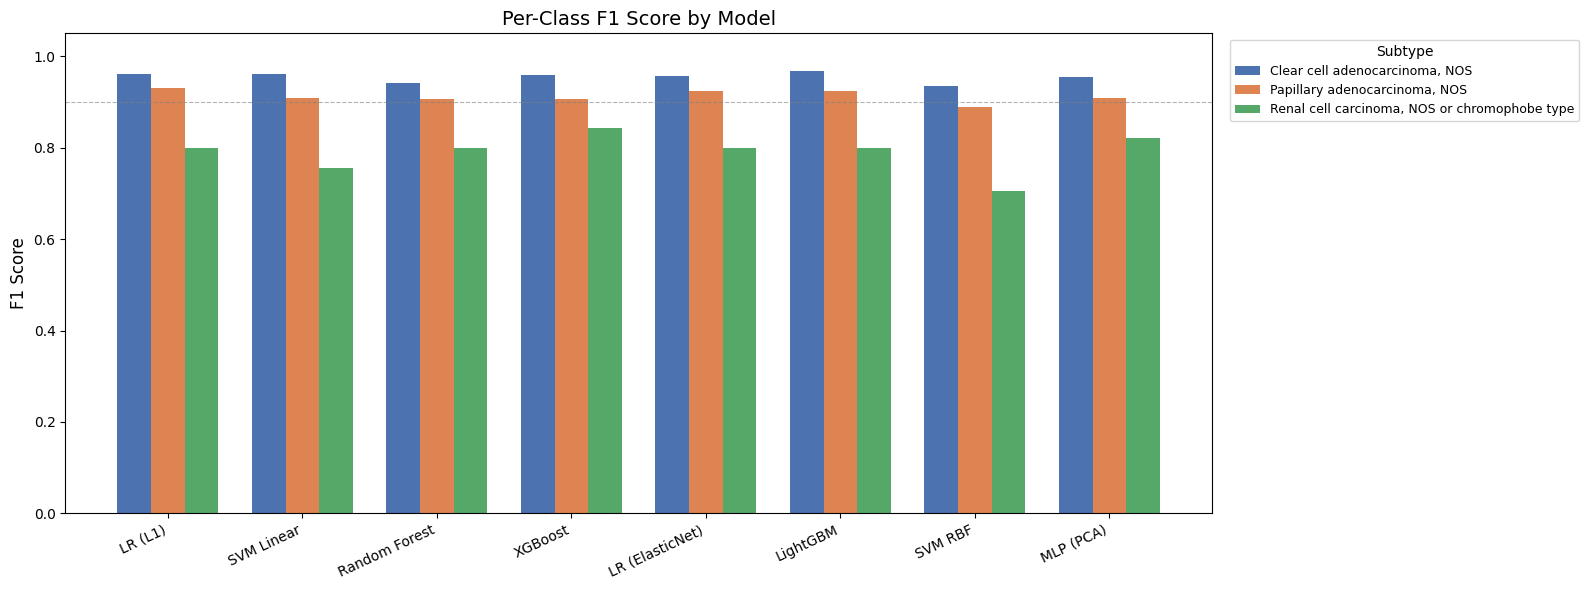

In [30]:
# ── PER-CLASS F1 BAR CHART ────────────────────────────────────────────────────
from sklearn.metrics import f1_score

model_names = ['LR (L1)', 'SVM Linear', 'Random Forest', 'XGBoost',
               'LR (ElasticNet)', 'LightGBM', 'SVM RBF', 'MLP (PCA)']

all_preds = [y_pred_lr_l1, y_pred_svm_linear, y_pred_clf, y_pred_xg,
             y_pred_lr_en, y_pred_lgbm, y_pred_rbf, y_pred_mlp]

# Compute per-class F1 for each model
f1_per_class = np.array([
    f1_score(y_test, preds, average=None) for preds in all_preds
])  # shape: (8 models, 3 classes)

x = np.arange(len(model_names))
width = 0.25
colors = ['#4C72B0', '#DD8452', '#55A868']

fig, ax = plt.subplots(figsize=(16, 6))

for i, (cls, color) in enumerate(zip(le.classes_, colors)):
    ax.bar(x + i * width, f1_per_class[:, i], width, label=cls, color=color)

ax.set_xticks(x + width)
ax.set_xticklabels(model_names, rotation=25, ha='right', fontsize=10)
ax.set_ylabel('F1 Score', fontsize=12)
ax.set_title('Per-Class F1 Score by Model', fontsize=14)
ax.set_ylim(0, 1.05)
ax.legend(title='Subtype', bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=9)
ax.axhline(y=0.9, color='grey', linestyle='--', linewidth=0.8, alpha=0.6)
plt.tight_layout()
plt.show()

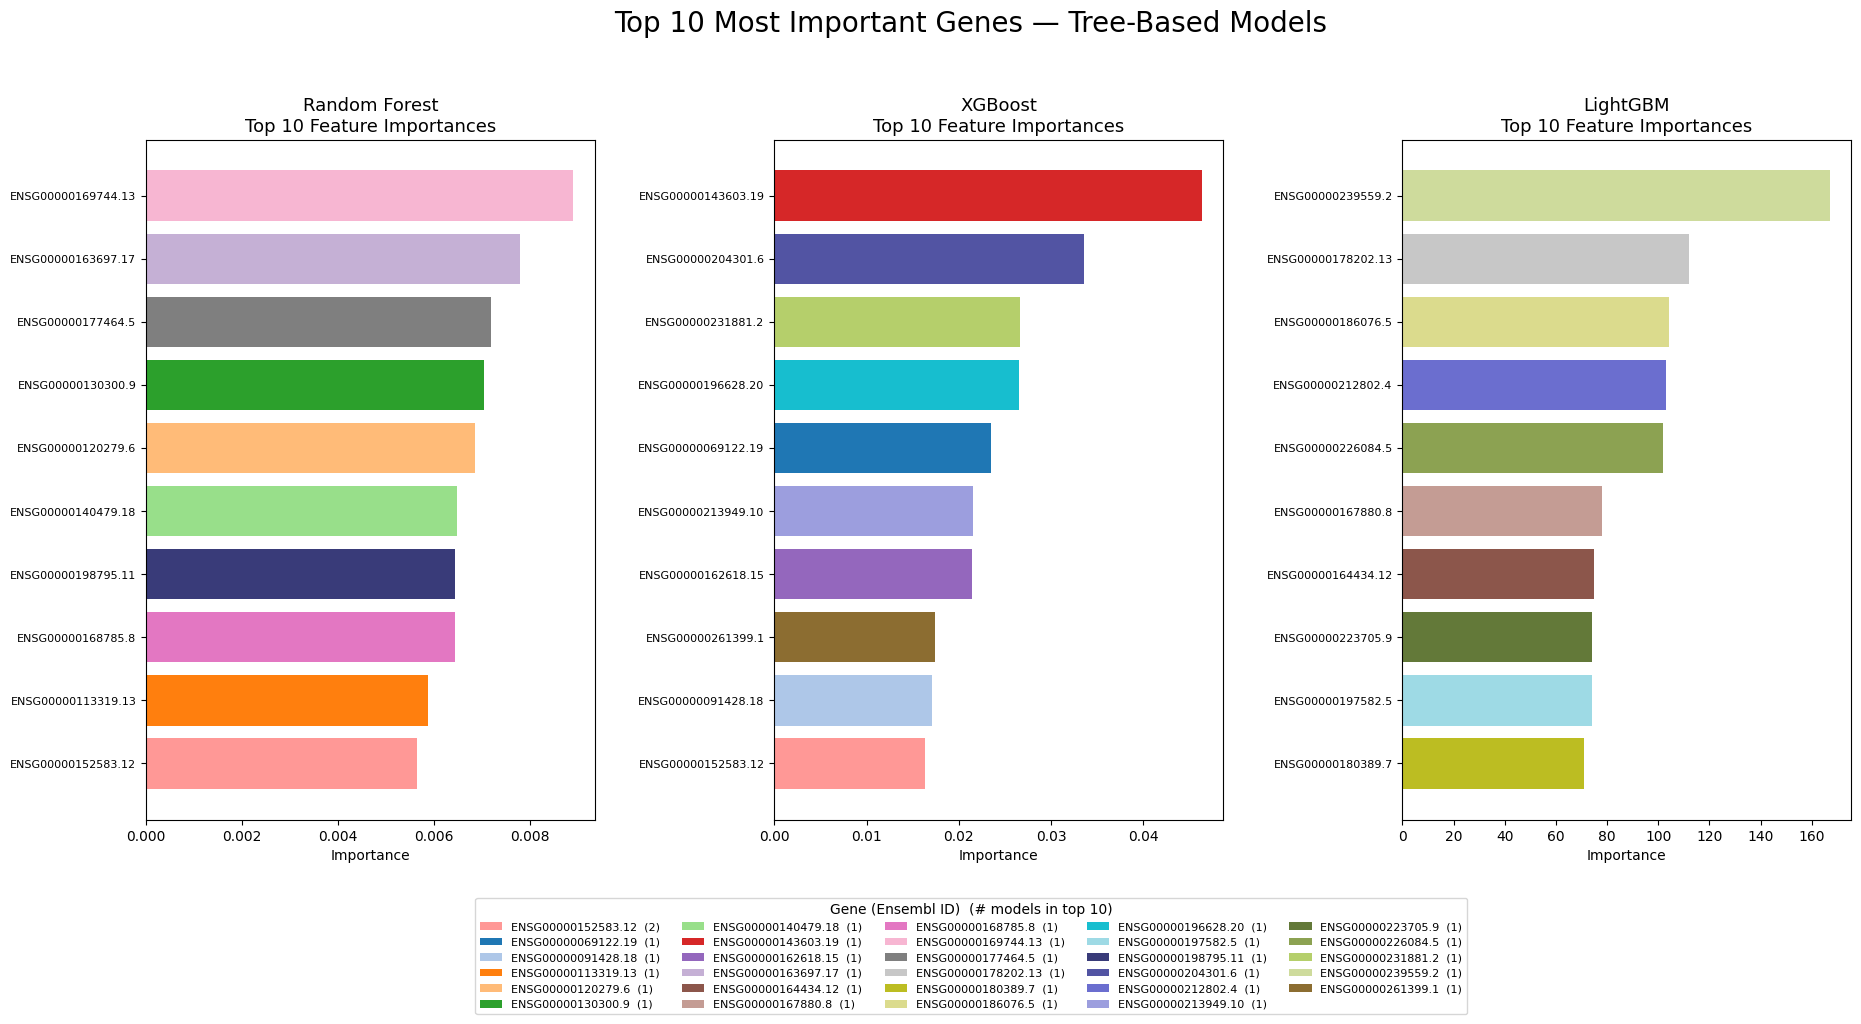

In [ ]:
# ── FEATURE IMPORTANCE ────────────────────────────────────────────────────────
top_n = 10

# Get top genes for each model
rf_importances   = pd.Series(clf.feature_importances_,     index=X_train.columns)
xgb_importances  = pd.Series(xgboost.feature_importances_, index=X_train.columns)
lgbm_importances = pd.Series(lgbm.feature_importances_,    index=X_train.columns)

rf_top   = rf_importances.nlargest(top_n).sort_values()
xgb_top  = xgb_importances.nlargest(top_n).sort_values()
lgbm_top = lgbm_importances.nlargest(top_n).sort_values()

# Build a shared color map across ALL unique genes in any top-20 list
all_genes = sorted(set(rf_top.index) | set(xgb_top.index) | set(lgbm_top.index))
palette = plt.cm.tab20.colors + plt.cm.tab20b.colors   # 40 distinct colors
gene_color_map = {gene: palette[i % len(palette)] for i, gene in enumerate(all_genes)}

# Create figure with extra space at the bottom for the legend
fig, axes = plt.subplots(1, 3, figsize=(22, 10))
plt.subplots_adjust(bottom=0.2, wspace=0.4)  # reserve space below the plots for the key

for ax, importances, title in zip(
    axes,
    [rf_top, xgb_top, lgbm_top],
    ['Random Forest', 'XGBoost', 'LightGBM']
):
    colors = [gene_color_map[gene] for gene in importances.index]
    ax.barh(importances.index, importances.values, color=colors)
    ax.set_title(f'{title}\nTop {top_n} Feature Importances', fontsize=13)
    ax.set_xlabel('Importance', fontsize=10)
    ax.tick_params(axis='y', labelsize=8)

plt.suptitle('Top 10 Most Important Genes — Tree-Based Models', fontsize=20, y=1.01)

# ── LEGEND / KEY ─────────────────────────────────────────────────────────────
# Build one legend patch per unique gene, placed below the subplots
# Count how many top-10 lists each gene appears in
gene_counts = {
    gene: sum([
        gene in rf_top.index,
        gene in xgb_top.index,
        gene in lgbm_top.index
    ])
    for gene in all_genes
}

# Sort genes by count descending, then alphabetically as tiebreaker
all_genes_sorted = sorted(all_genes, key=lambda g: (-gene_counts[g], g))

# Rebuild legend handles with count in the label
legend_handles = [
    Patch(facecolor=gene_color_map[gene], label=f"{gene}  ({gene_counts[gene]})")
    for gene in all_genes_sorted
]

fig.legend(
    handles=legend_handles,
    title='Gene (Ensembl ID)  (# models in top 10)',
    loc='lower center',
    bbox_to_anchor=(0.5, 0.0),
    ncol=5,
    fontsize=8,
    title_fontsize=10,
    frameon=True
)
plt.show()